# 02 - Reversible training at the SAME batch size: which variant works best?

**Goal (assignment part 2).** Re-train with a *reversible* transformer at the batch size fixed in
notebook 01, and compare the reversible update rules:

| variant | update rule | note |
|---|---|---|
| `midpoint` | `x[l+1] = x[l-1] + 2h f(x[l])` | 2-step rule from the paper |
| `leapfrog` | `x[l+1] = 2x[l] - x[l-1] + h^2 f(x[l])` | 2nd-order, wave-equation style |
| `hamiltonian` | `q' = q + Attn(p);  p' = p + MLP(q')` | symplectic-Euler ("Euler-style") |

All variants have exactly the same parameters as the baseline. Report which one wins on loss.

In [1]:
SMOKE = False   # True = tiny CPU version of this whole notebook (used to test the code; not for results)
REPO_URL = "https://github.com/pratik-2025/Asisgnment13_Reversible_LLM_20M"   # <- edit: only needed on Colab
USE_DRIVE = True   # True = keep data + results on Google Drive so they survive a Colab disconnect

import os, sys, copy, json, subprocess
if os.path.exists("../revlm"):
    os.chdir("..")                                   # opened from the notebooks/ folder
elif not os.path.exists("revlm"):
    assert "YOUR-USERNAME" not in REPO_URL, "edit REPO_URL (top of this cell) to point at your GitHub repo"
    subprocess.run(["git", "clone", REPO_URL, "repo"], check=True)   # fresh Colab VM
    os.chdir("repo")
sys.path.insert(0, os.getcwd())
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "tokenizers", "datasets"], check=False)

import torch
from IPython.display import Image, display
from revlm import selftest, experiment as ex
from revlm.bench import bench_steps, scaling_table
from revlm.data import prepare_data, Data
from revlm.report import write_summary, plot_scaling

S = ex.settings(SMOKE)
DEV = ex.device()
RESULTS = "results_smoke" if SMOKE else "results"
DATA_DIR = "data_smoke" if SMOKE else "data"
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    RESULTS = "/content/drive/MyDrive/reversible-llm-20m/" + RESULTS
    DATA_DIR = "/content/drive/MyDrive/reversible-llm-20m/" + DATA_DIR
print("device:", DEV, torch.cuda.get_device_name() if DEV == "cuda" else "(no GPU!)" if not SMOKE else "(smoke test)")
if DEV != "cuda" and not SMOKE:
    print("WARNING: no GPU. In Colab use Runtime > Change runtime type > GPU.")

Mounted at /content/drive
device: cuda Tesla T4


## 0. Sanity check

In [2]:
# 30-second correctness check on THIS machine/GPU before spending an hour of compute.
assert selftest.main(DEV), "self-test failed - do not trust any numbers below"

device=cuda
1. params identical across modes: 53728


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


2. reconstruction max |error| (float64): {'midpoint': '4.4e-16', 'leapfrog': '8.9e-16', 'hamiltonian': '2.2e-16'}
3. memory-saving vs autograd (loss diff, worst rel. grad diff): {'midpoint': ('0.0e+00', '1.2e-15'), 'leapfrog': ('0.0e+00', '1.6e-15'), 'hamiltonian': ('0.0e+00', '9.5e-16')}
4. chunked vs normal loss (loss diff, rel. grad diff): {'baseline': ('8.9e-16', '4.1e-16'), 'midpoint': ('0.0e+00', '3.1e-16')}
4b. mixed-precision grad cosine(memory-saving, autograd): {'midpoint': '1.00000', 'leapfrog': '1.00000', 'hamiltonian': '1.00000'}
ALL CHECKS PASSED


## 1. Data

In [3]:
# Downloads TinyStories, trains an 8k BPE tokenizer, writes exactly 50M training tokens (~3-6 min, cached).
prepare_data(DATA_DIR, vocab_size=8192, **S["data"])
data = Data(DATA_DIR, S["model"].ctx, seed=1337)
print(f"train tokens available: {len(data.train):,}   validation tokens: {len(data.val):,}   sequences: {data.n_seq:,}")

train tokens available: 50,000,000   validation tokens: 1,000,000   sequences: 97,656


In [4]:
def mk(mode, **over):
    """20M-parameter model config in the given mode (same weights/shape for every mode)."""
    mc = copy.deepcopy(S["model"]); mc.mode = mode
    for k, v in over.items():
        setattr(mc, k, v)
    return mc

from revlm.model import GPT
print(f"parameters: {GPT(mk('baseline')).num_params()/1e6:.2f}M   (layers={S['model'].n_layer}, d_model={S['model'].d_model}, vocab={S['model'].vocab_size}, ctx={S['model'].ctx})")

parameters: 20.01M   (layers=14, d_model=320, vocab=8192, ctx=512)


In [5]:
saved = ex.load(RESULTS, "fixed_batch")
B_FIXED = saved["B_fixed"] if saved else None      # <- if you skipped notebook 01, type the batch size here
assert B_FIXED, "run notebook 01 first (or set B_FIXED by hand)"
print("using batch size", B_FIXED)

using batch size 104


## 2. Quick speed / memory check at the fixed batch (5 real training steps each)

In [6]:
bench = {}
for mode in ["baseline", "midpoint", "leapfrog", "hamiltonian"]:
    r = bench_steps(mk(mode), B_FIXED, DEV, "auto", n_steps=6)
    bench[mode] = r
    print(f"{mode:12s} ok={r['ok']}  peak={r['peak_mib']}  tok/s={r['tokens_per_sec']}")
ex.save(RESULTS, "bench_fixed_batch", bench)

baseline     ok=True  peak=13644.11474609375  tok/s=76722.74500939152
midpoint     ok=True  peak=5409.03662109375  tok/s=58641.94397431847
leapfrog     ok=True  peak=5408.97412109375  tok/s=54744.832385923015
hamiltonian  ok=True  peak=5406.56787109375  tok/s=58423.61576161924


## 3. Train all three reversible variants for 50M tokens

In [7]:
variants = {}
for mode in ["midpoint", "leapfrog", "hamiltonian"]:
    variants[mode] = ex.run_or_load(mk(mode), ex.make_train_cfg(S, f"02_{mode}", B_FIXED), data, RESULTS)

[02_midpoint] mode=midpoint h=0.5 B=104 steps=939 params=20.01M amp=torch.float16 lr_peak=1.27e-03
  step     1/939 tokens   0.05M loss 9.0448      3506 tok/s mem    5254 MiB
  step    21/939 tokens   1.12M loss 6.9670     53202 tok/s mem    5409 MiB
  step    41/939 tokens   2.18M loss 5.3885     48721 tok/s mem    5409 MiB
  step    61/939 tokens   3.25M loss 4.6535     49454 tok/s mem    5409 MiB
  step    81/939 tokens   4.31M loss 4.2639     51574 tok/s mem    5409 MiB
  >> val loss 4.1073 at 5.0M tokens
  step   101/939 tokens   5.38M loss 4.0890     50566 tok/s mem    5409 MiB
  step   121/939 tokens   6.44M loss 3.9867     49971 tok/s mem    5409 MiB
  step   141/939 tokens   7.51M loss 3.8879     50082 tok/s mem    5409 MiB
  step   161/939 tokens   8.57M loss 3.8157     50659 tok/s mem    5409 MiB
  step   181/939 tokens   9.64M loss 3.7256     50092 tok/s mem    5409 MiB
  >> val loss 3.7205 at 9.9M tokens
  step   201/939 tokens  10.70M loss 3.6356     50150 tok/s mem    54

## 4. Optional: does the step size `h` matter? (short pilot, off by default)
`h` is the step size of midpoint / leapfrog. The default `h = 0.5` makes midpoint's step `2h = 1`,
the same size as the baseline's residual step. Turn this on to test 0.25 / 0.5 / 1.0 on 5M tokens.

In [8]:
RUN_H_SWEEP = False
if RUN_H_SWEEP:
    S_pilot = dict(S, total_tokens=5_000_000 if not SMOKE else 200_000, eval_every_tokens=2_500_000 if not SMOKE else 100_000)
    for mode in ["midpoint", "leapfrog"]:
        for h in [0.25, 0.5, 1.0]:
            tc = ex.make_train_cfg(S_pilot, f"hsweep_{mode}_h{h}", B_FIXED)
            r = ex.run_or_load(mk(mode, h=h), tc, data, RESULTS + "/hsweep")
            print(mode, h, "val loss", round(r["final_val_loss"], 4), "diverged" if r["diverged"] else "")

## 5. Which variant wins?

In [9]:
base = ex.load(RESULTS, "01_baseline")
ok = {m: r for m, r in variants.items() if not r["diverged"] and r["final_val_loss"] == r["final_val_loss"]}
winner = min(ok, key=lambda m: ok[m]["final_val_loss"])
ex.save(RESULTS, "winner", {"winner": winner, "h": ok[winner]["model"]["h"]})
print(f"{'run':14s}{'val loss':>10s}{'tok/s':>10s}{'peak MiB':>10s}")
for name, r in [("baseline", base)] + list(variants.items()):
    if r: print(f"{name:14s}{r['final_val_loss']:10.4f}{r['tokens_per_sec_median']:10,.0f}{(r['peak_mem_allocated_mib'] or 0):10,.0f}")
print("winner (lowest validation loss):", winner)

run             val loss     tok/s  peak MiB
baseline          2.1885    62,963    13,644
midpoint          2.3055    50,283     5,409
leapfrog          2.1478    47,812     5,406
hamiltonian       2.4389    51,615     5,407
winner (lowest validation loss): leapfrog


## 6. Does memory really stop growing with depth? (baseline vs the winner)
Fixed batch, more and more layers, then longer sequences. Reversible memory should stay almost flat
in depth; the baseline's should grow linearly.

depth scaling
    baseline     n_layer=7     peak 3000 MiB  111443 tok/s
    leapfrog     n_layer=7     peak 1739 MiB  87187 tok/s
    baseline     n_layer=14    peak 4380 MiB  65023 tok/s
    leapfrog     n_layer=14    peak 1838 MiB  47958 tok/s
    baseline     n_layer=28    peak 7141 MiB  34791 tok/s
    leapfrog     n_layer=28    peak 2038 MiB  25339 tok/s
    baseline     n_layer=56    peak 12663 MiB  18140 tok/s
    leapfrog     n_layer=56    peak 2435 MiB  12824 tok/s
sequence-length scaling
    baseline     ctx=256   peak 1309 MiB  63097 tok/s
    leapfrog     ctx=256   peak 656 MiB  47168 tok/s
    baseline     ctx=512   peak 2346 MiB  62811 tok/s
    leapfrog     ctx=512   peak 1045 MiB  46347 tok/s
    baseline     ctx=1024  peak 4382 MiB  57038 tok/s
    leapfrog     ctx=1024  peak 1842 MiB  42235 tok/s
    baseline     ctx=2048  peak 8481 MiB  48316 tok/s
    leapfrog     ctx=2048  peak 3431 MiB  36151 tok/s


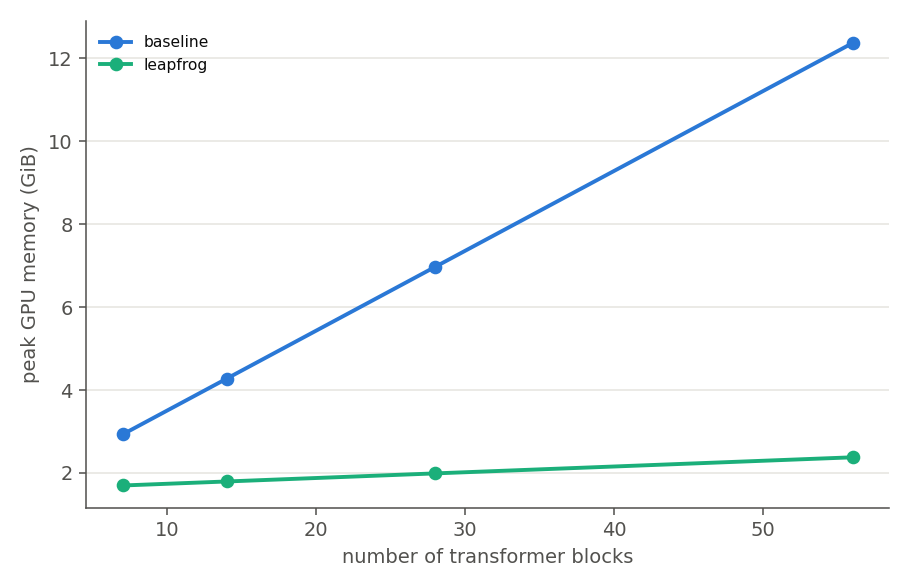

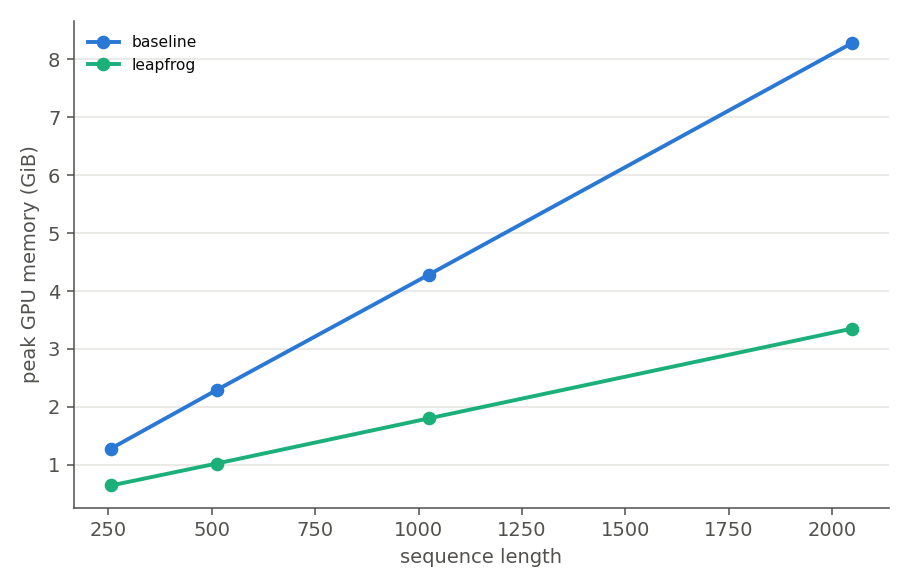

In [10]:
variants_cfg = [("baseline", {"mode": "baseline"}), (winner, {"mode": winner})]
print("depth scaling"); rows_d = scaling_table(S["model"], variants_cfg, DEV, "auto", S["bench_batch"], "n_layer", S["depths"])
print("sequence-length scaling"); rows_c = scaling_table(S["model"], variants_cfg, DEV, "auto", max(1, S["bench_batch"] // 2), "ctx", S["ctxs"])
ex.save(RESULTS, "depth_scaling", {"rows": rows_d}); ex.save(RESULTS, "ctx_scaling", {"rows": rows_c})
if DEV == "cuda":
    plot_scaling(rows_d, "n_layer", f"{RESULTS}/depth_scaling.png", "number of transformer blocks")
    plot_scaling(rows_c, "ctx", f"{RESULTS}/ctx_scaling.png", "sequence length")
    display(Image(f"{RESULTS}/depth_scaling.png")); display(Image(f"{RESULTS}/ctx_scaling.png"))

## 7. Loss curves and summary table

| run | mode | batch | steps | tokens seen | final train loss | final val loss | tokens/s (median) | peak mem (GiB) | wall time (min) |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|
| 01_baseline | baseline | 104 | 939 | 50.0M | 2.1417 | 2.1885 | 62,963 | 13.32 | 14.2 |
| 02_hamiltonian | hamiltonian | 104 | 939 | 50.0M | 2.3914 | 2.4389 | 51,615 | 5.28 | 17.1 |
| 02_leapfrog | leapfrog | 104 | 939 | 50.0M | 2.0984 | 2.1478 | 47,812 | 5.28 | 18.5 |
| 02_midpoint | midpoint | 104 | 939 | 50.0M | 2.2606 | 2.3055 | 50,283 | 5.28 | 17.8 |


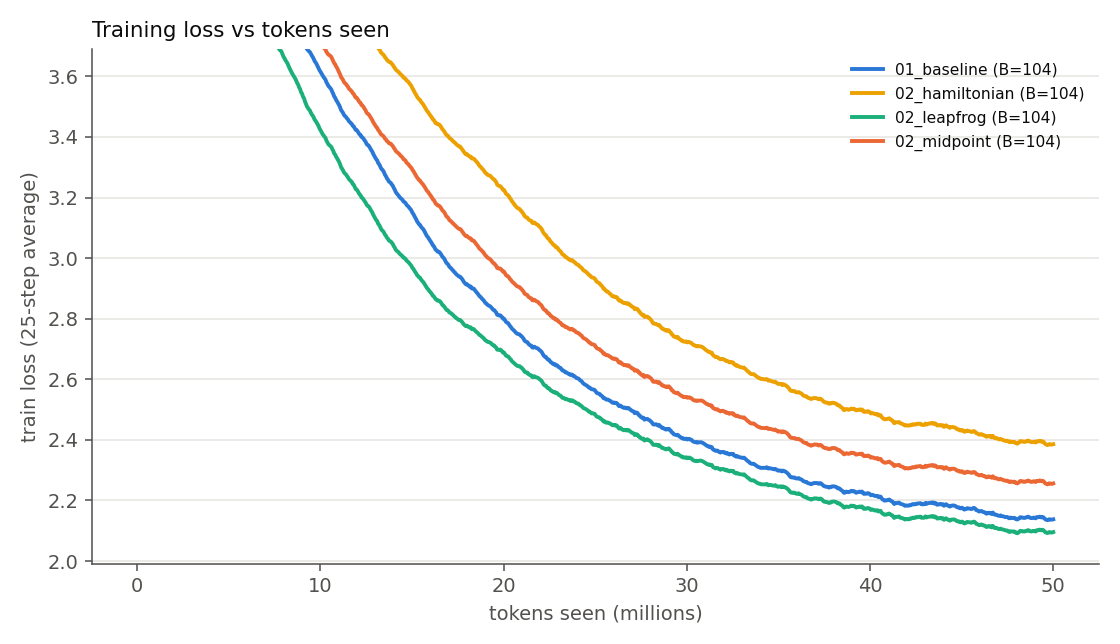

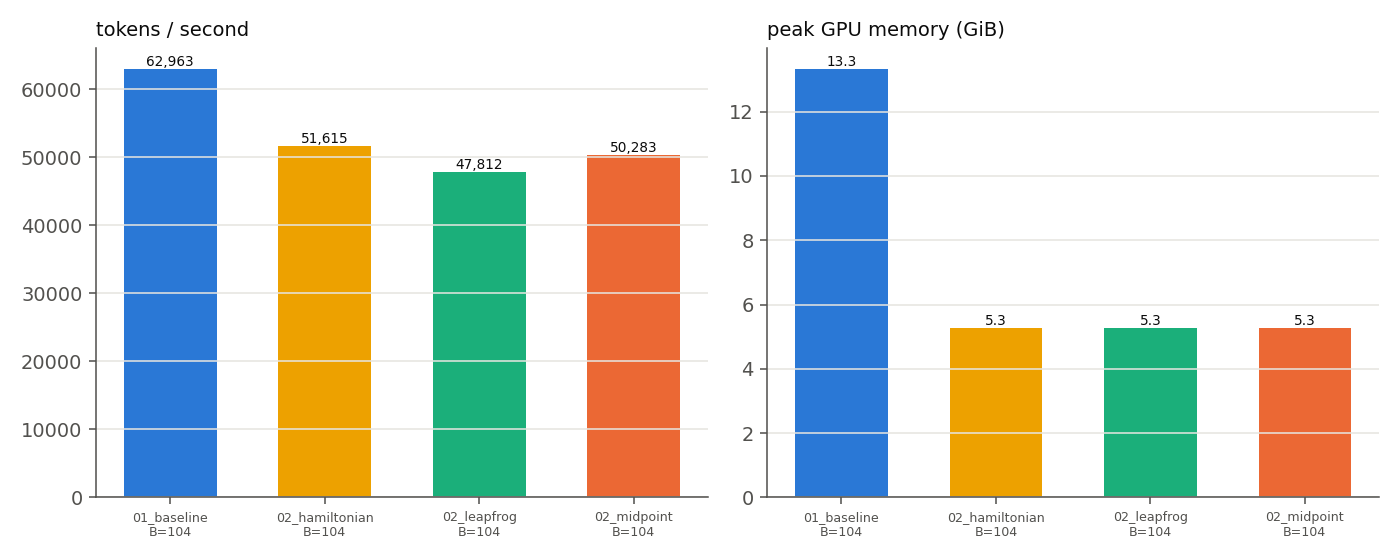

In [11]:
write_summary(RESULTS)
display(Image(f"{RESULTS}/loss_curves.png")); display(Image(f"{RESULTS}/speed_memory.png"))